# SDOCX Format — Ink Properties

Each stroke's delta data blob contains more than just coordinates. After the coordinate
deltas, there's a **trailing section** with per-point attribute channels (pressure,
timestamp, tilt) and per-stroke properties (color, pen width).

This notebook decodes all of it and produces a full-fidelity rendering.

In [1]:
from pathlib import Path

SAMPLE_HANDWRITTEN = Path("../samples/handwritten.sdocx")
SAMPLE_MEDIA = Path("../samples/quiz.sdocx")
# SAMPLE_HANDWRITTEN = Path("../samples/OnlyPensBlacksize10_260630_120309.sdocx")
SAMPLE_HANDWRITTEN = Path("../samples/OnlyHighlighterBlack_260630_131753.sdocx")
SAMPLE_HANDWRITTEN = Path("../samples/Allsamsungnotes_260630_113259.sdocx")
SAMPLE_HANDWRITTEN = Path("../samples/OnlyShapesblack_260701_173146.sdocx")
SAMPLE_HANDWRITTEN = Path("../samples/OnlyShapesblack_new_260701_185935.sdocx")

In [ ]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from pysdocx import (
    hexdump,
    list_pages,
    load_page_with_bg,
    parse_page,
    decode_trailing,
    color_hex,
)
from pysdocx.render import render_document

In [3]:
MAX_PRESSURE = 1400.0

In [4]:
page_key, page, bg_color = load_page_with_bg(SAMPLE_HANDWRITTEN)
print(f"Page: {len(page):,} bytes")
print(f"Background: {bg_color}")

Page: 138,166 bytes
Background: #252525


In [5]:
result = parse_page(page)
strokes = result["strokes"]
print(f"Parsed {result['kept']} / {result['stroke_count']} strokes")

Parsed 111 / 153 strokes


---

## Trailing Data Structure

Each stroke's data blob has two regions:

```
+------------------------+----------------------------------------------+
|   Coordinate Deltas    |  Trailing: channels + stroke properties      |
|   (4 bytes per point)  |  [4B gap] [pressure] [time] [tilt] [color+w] |
+------------------------+----------------------------------------------+
```

The trailing section starts **4 bytes** after the coordinate data ends. It contains
**four per-point channels**, each encoded as sign-magnitude byte pairs (same encoding
as coordinates, but 1D — no x/y interleaving), followed by **per-stroke color and pen
width** at the very end.

In [6]:
s = strokes[0]
blob = s["data_blob"]
nc = s["n_coord_bytes"]
n_pts = len(s["points"]) - 1  # delta count (excludes start point)

print(f"Stroke 0: {len(s['points'])} points, {len(blob)} data bytes")
print(f"  Coordinate data:   {nc} bytes")
print(f"  Trailing data:     {len(blob) - nc} bytes")
print(f"  Delta points:      {n_pts}")
print(f"  Per-channel size:  {n_pts * 2} bytes")
print(f"  4 channels + gap:  {n_pts * 2 * 4 + 4} bytes")

Stroke 0: 4 points, 16513 data bytes
  Coordinate data:   12 bytes
  Trailing data:     16501 bytes
  Delta points:      3
  Per-channel size:  6 bytes
  4 channels + gap:  28 bytes


In [7]:
print("Trailing data (first 64 bytes):")
print(hexdump(blob[nc:], limit=64))

Trailing data (first 64 bytes):
  0000  00 00 0c 00 00 00 6e 59 cb 40 00 00 00 00 00 00  ······nY·@······
  0010  00 00 1c 01 00 00 07 00 a7 00 00 00 01 04 04 01  ················
  0020  00 00 00 04 00 00 00 00 00 00 80 f7 92 6b 40 00  ·············k@·
  0030  00 00 00 5d 39 79 40 00 00 00 40 7a c3 76 40 00  ···]9y@···@z·v@·
  ... (16437 more bytes)


---

## Per-Stroke Color, Width, Tool, and Intensity

Color, pen tool, and pen width are stored at the **end** of the data blob (within the last
~100 bytes — search only the tail, not the whole blob, or you'll occasionally match this same
6-byte shape by coincidence inside the per-point channel data on long, low-variance strokes),
preceded by a 6-byte marker:

```
02 00 TT 00 00 00
```

`TT` encodes **which pen tool** drew the stroke: `tool_id = (TT - 1) / 2`. This is **not a
single global registry** — confirmed on two ground-truth files (one stroke/size per tool,
left to right):

- `samples/OnlyPensBlacksize10_*.sdocx`: `0`=pen, `1`=fountain pen, `2`=calligraphy pen,
  `3`=pencil, `4`=calligraphy brush (all odd `TT`).
- `samples/OnlyHighlighterBlack_*.sdocx`: "highlighter" reuses `TT=1` (same as "pen"!),
  "marker pen" uses `TT=4` (even). The two "straight-line" (ruler-mode) variants use a
  **short-form marker** without the leading `02 00`: `[TT 00 00 00] [BGRA] [f32 width]`.

After the marker, the layout is either `[BGRA][f32 width]` (explicit color) or `[f32 width]`
directly (default ink, no color):

- **alpha (4th color byte) `= 0xFF`** → full-opacity color, then width.
- **leading 4 bytes are a sane width float** → no color, width stored directly (default ink).
- **otherwise** → reduced-opacity color, where the **alpha byte is the pen's "intensità"
  (opacity) slider**: e.g. pencil at intensity 100 = alpha `0xFF`, intensity 50 = `0x80`,
  intensity 0 = `0x03` (low but non-zero — still faintly visible, as in the app). Decoded into
  the per-stroke `intensity` field (0-255).

Ink-pen-category tools also carry a 12-byte block after the width (`[u32 = 2·tool_id][width
repeated]`) that highlighter/marker tools lack — this is the `tapered` flag (pressure-sensitive
nib vs. flat felt tip).

In [8]:
colors = {}
widths = []

for s in strokes:
    key = color_hex(s["color"]) or "(default)"
    colors[key] = colors.get(key, 0) + 1
    widths.append(s["pen_width"])

print("Color distribution:\n")
for color, count in sorted(colors.items(), key=lambda x: -x[1]):
    print(f"  {color:<12} {count:>5} strokes")

# tool_id is a per-category slot index, not a global tool registry (see the
# markdown above) — only label it by name if you know which ground-truth
# file is loaded; otherwise just look at the raw id.
print("\nPer-stroke tool_id/width (sorted left-to-right by bbox.x_min — compare")
print("against the order you actually drew the strokes in, if this is a ground-truth file):\n")
print(f"  {'idx':>4} {'tool_id':>7} {'width':>7} {'x_min':>8}")
for idx, s in sorted(enumerate(strokes), key=lambda pair: pair[1]["bbox"][0]):
    print(f"  {idx:>4} {str(s['tool_id']):>7} {s['pen_width']:>7.2f} {s['bbox'][0]:>8.1f}")

Color distribution:

  #252525        109 strokes
  (default)        2 strokes

Per-stroke tool_id/width (sorted left-to-right by bbox.x_min — compare
against the order you actually drew the strokes in, if this is a ground-truth file):

   idx tool_id   width    x_min
    79    None    0.80      0.0
     0    None    0.80      0.0
    80       0    6.35    681.3
    81       0    6.35    720.1
    82       0    6.35    789.3
    83       0    6.35    791.5
    84       0    6.35    870.6
    86       0    6.35    928.0
    85       0    6.35    928.8
    88       0    6.35    970.2
    87       0    6.35    971.1
    89       0    6.35   1003.8
    90       0    6.35   1006.4
    91       0    6.35   1013.2
    92       0    6.35   1036.8
    93       0    6.35   1070.4
    94       0    6.35   1076.3
    95       0    6.35   1157.5
    96       0    6.35   1186.5
    97       0    6.35   1214.8
    98       0    6.35   1247.6
    49       0    6.35   1260.6
    60       0    6.35   12

In [9]:
print(f"Pen width range: {min(widths):.2f} \u2013 {max(widths):.2f}")
print(f"Unique widths:   {sorted(set(f'{w:.2f}' for w in widths))}")

Pen width range: 0.80 – 6.35
Unique widths:   ['0.80', '6.35']


---

## Per-Point Pressure

The first per-point channel encodes **pen pressure**. Like coordinates, it uses
sign-magnitude byte pairs — but these are **1D deltas** (not x/y pairs).

Each pair: `(magnitude, sign_flag)` where `0x00` = positive, `0x80` = negative.

The cumulative sum of pressure deltas gives the actual raw pressure at each point,
ranging **0–~1400**, with a characteristic ramp-up at pen-down and sharp drop at
pen-lift. `pysdocx.decode_trailing` (already run for us inside `parse_page`)
normalizes this to **0.0–1.0** and stores it on each stroke as `pressures`.

In [10]:
has_pressure = sum(1 for s in strokes if s["pressures"])
print(f"Strokes with pressure data: {has_pressure} / {len(strokes)}")

Strokes with pressure data: 111 / 111


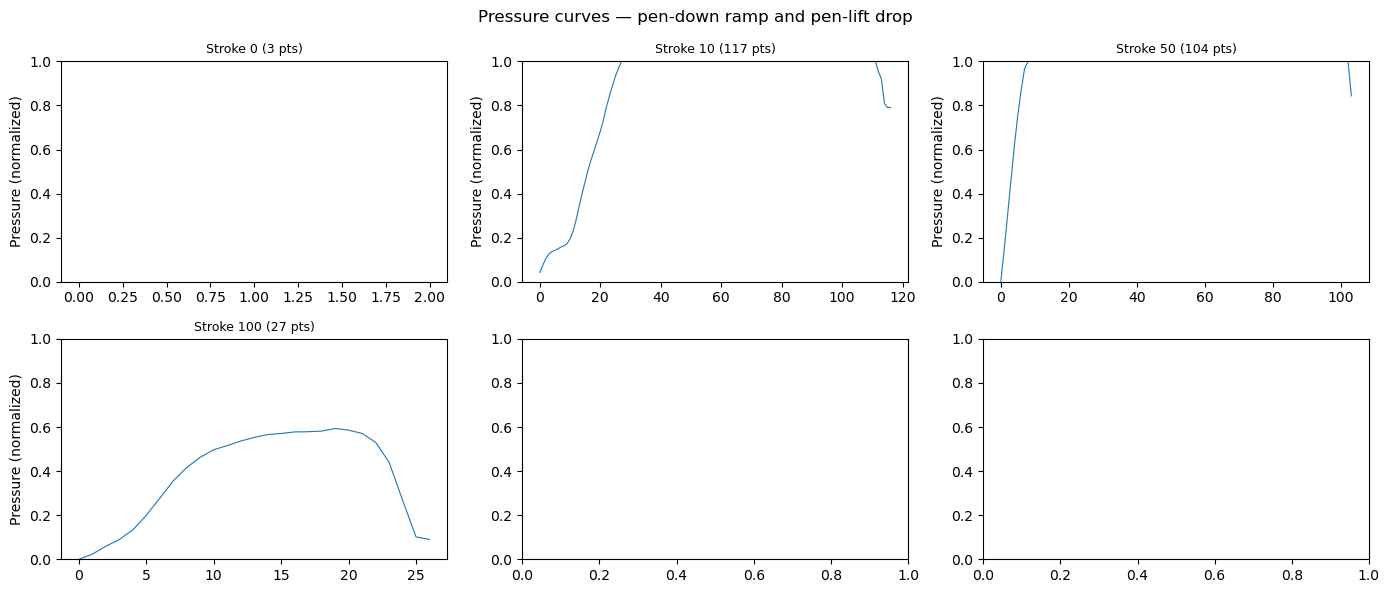

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for ax, idx in zip(axes.flat, [0, 10, 50, 100, 500, 1000]):
    if idx < len(strokes) and strokes[idx]["pressures"]:
        p = strokes[idx]["pressures"]
        ax.plot(p, linewidth=0.8)
        ax.set_title(f"Stroke {idx} ({len(p)} pts)", fontsize=9)
        ax.set_ylabel("Pressure (normalized)")
        ax.set_ylim(0, 1)

fig.suptitle(
    "Pressure curves — pen-down ramp and pen-lift drop",
    fontsize=12,
)
plt.tight_layout()
plt.show()

---

## All Per-Point Channels

After the 4-byte gap, there are **four consecutive channels**, each with `n_points`
sign-magnitude delta pairs:

| Channel | Offset from trail start | Content |
|---------|------------------------|---------|
| 0 | `0` | Pressure (0–1400) |
| 1 | `n_points x 2` | Timestamp (monotonic) |
| 2 | `n_points x 4` | Tilt X |
| 3 | `n_points x 6` | Tilt Y |

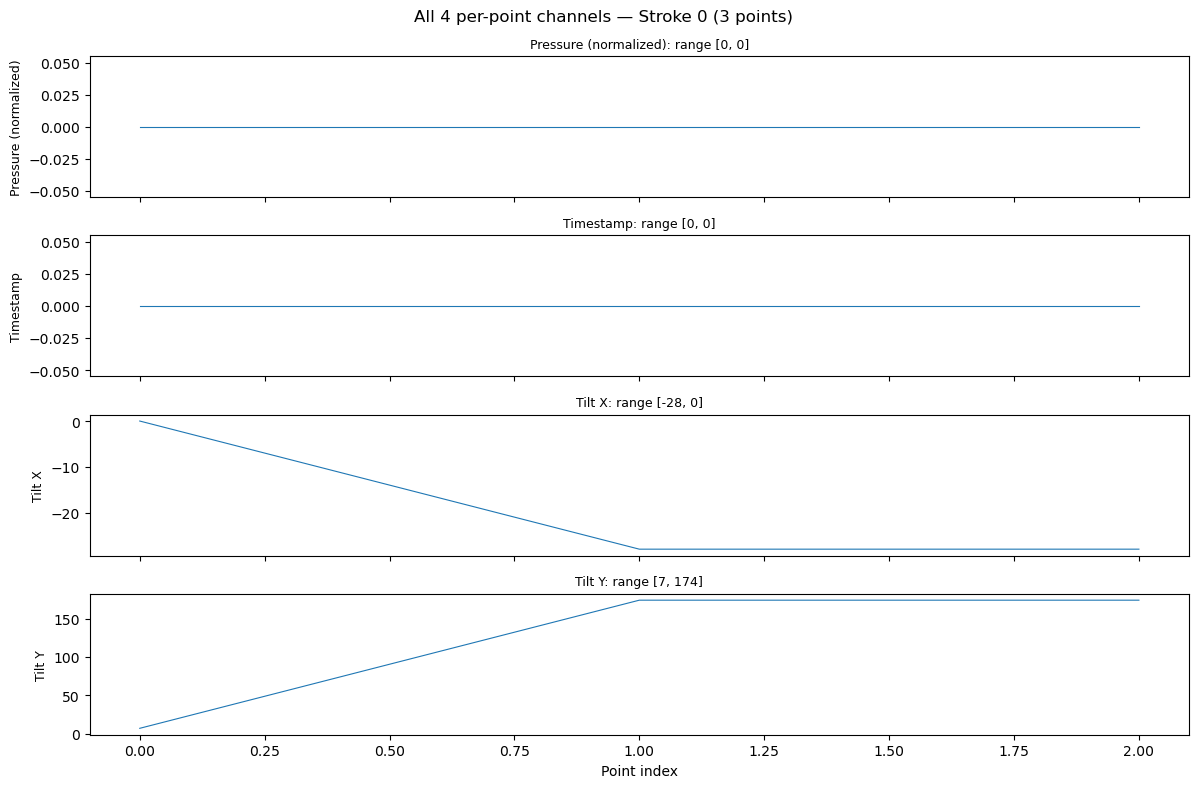

In [12]:
s = strokes[0]
n_pts = len(s["points"]) - 1
trailing = decode_trailing(s["data_blob"], s["n_coord_bytes"], n_pts)
channels = [trailing["pressures"], trailing["timestamps"], trailing["tilt_x"], trailing["tilt_y"]]
ch_names = ["Pressure (normalized)", "Timestamp", "Tilt X", "Tilt Y"]

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, ch, name in zip(axes, channels, ch_names):
    if ch:
        ax.plot(ch, linewidth=0.8)
        ax.set_ylabel(name, fontsize=9)
        ax.set_title(f"{name}: range [{min(ch):.3g}, {max(ch):.3g}]", fontsize=9)
axes[-1].set_xlabel("Point index")
fig.suptitle(
    f"All 4 per-point channels — Stroke 0 ({n_pts} points)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

---

## Full Rendering

Combining everything: coordinates from delta decoding, per-stroke color from the
color marker, and per-point pressure for variable stroke width.

Width formula:
```
base_width  = pen_width / 2.5
segment_width = base_width x (0.3 + 0.7 x normalized_pressure)
```

Where `normalized_pressure = clamp(cumulative_pressure / 1400, 0, 1)`.

In [ ]:
# All rendering now lives in pysdocx.render — draw the single loaded page (page 1).
# See render_page / render_shape / render_document there for the full logic.
render_document(SAMPLE_HANDWRITTEN, page=1)

---

## Multi-Page Rendering

Multi-page files (e.g. the benchmark `Allsamsungnotes_*.sdocx`) have several `.page` entries.
`list_pages` returns them in **true document order** (from `pageIdInfo.dat`, not sorted by UUID —
sorting scrambles the order). Each page is rendered full size, one below the other, with its
page index, UUID, parsed/total stroke counts (flagging any mismatch), and background color.

In [15]:
all_pages = list_pages(SAMPLE_HANDWRITTEN)
print(f"{len(all_pages)} page(s) in {SAMPLE_HANDWRITTEN.name} (document order):")
for i, page_name in enumerate(all_pages, start=1):
    _, page_bytes, _ = load_page_with_bg(SAMPLE_HANDWRITTEN, page_name)
    r = parse_page(page_bytes)
    flag = "  MISMATCH" if r["kept"] != r["stroke_count"] else ""
    shp = f"  +{len(r['shapes'])} shapes" if r["shapes"] else ""
    print(f"  page {i}: {page_name[:8]}  {r['kept']:>4}/{r['stroke_count']:<4} strokes{shp}{flag}")

9 page(s) in OnlyShapesblack_new_260701_185935.sdocx (document order):
  page 1: 8dbb2c34   111/153  strokes  +23 shapes  MISMATCH
  page 2: 8dbd2d7c    96/157  strokes  +18 shapes  MISMATCH
  page 3: a8f7d126   110/153  strokes  +23 shapes  MISMATCH
  page 4: c1ada90c   111/154  strokes  +23 shapes  MISMATCH
  page 5: eb31abd4   125/166  strokes  +23 shapes  MISMATCH
  page 6: 23922774    91/143  strokes  +15 shapes  MISMATCH
  page 7: 7deeffea   101/159  strokes  +17 shapes  MISMATCH
  page 8: 28663f36   172/240  strokes  +23 shapes  MISMATCH
  page 9: c8a48dd4     0/0    strokes


In [ ]:
# Render every page full size, one below the other, in true document order.
# The whole pipeline (strokes, shapes, imported images, freehand drawings, note-level typed text
# and table, the squared-grid template) is in pysdocx.render.render_document. Typed text / tables
# live once per document in note.note with no page reference, so their placement is a heuristic
# (typed text → first empty page; table → `table_page`, default 4), matching Samsung Notes.
render_document(SAMPLE_HANDWRITTEN)

---

## Complete SDOCX Format Summary

### Container (ZIP)

| File | Content |
|------|---------|
| `end_tag.bin` | Timestamps (i64 ms epoch), `"Document for S-Pen SDK"` |
| `pageIdInfo.dat` | Page UUID (UTF-16LE) + 2 x 32-byte hashes |
| `media/mediaInfo.dat` | Media filename + SHA-256 + `EOFX` |
| `note.note` | Title, pen tools, background color, dimensions |
| `media/*.spi` | Page thumbnail (Samsung proprietary) |
| `<uuid>.page` | Stroke data (see below) |

### Page file (`.page`)

**Header:**

| Offset | Type | Field |
|--------|------|-------|
| `0x00` | u32 | Base offset (`base`) |
| `0x16` | u32 | Page width |
| `0x1A` | u32 | Page height |
| `0x26` | u16 | UUID length (chars) |
| `0x28` | UTF-16LE | Page UUID |
| `0x80` | 4 x f64 | Content bounding box |
| `base + 0x66` | u32 | Stroke count |

**Stroke records** (starting at `base + 0xB5`, sequential):

| Part | Bytes | Format |
|------|-------|--------|
| Bounding box | 32 | 4 x f64 |
| Metadata | 41 | byte 21: u32 data_len; byte 39: u16 n_points |
| Start point | 16 | 2 x f64 |
| Delta data | data_len | See below |
| Inter-stroke | 71 | UUID + timestamp |

**Delta data layout:**

| Region | Encoding | Description |
|--------|----------|-------------|
| Coordinates | 4-byte groups: `[dx_mag, dx_sign, dy_mag, dy_sign]` | `0x00`=+, `0x80`=-, scale x 1/32 |
| 4-byte gap | — | Separator |
| Pressure | 2-byte pairs x n_points | Sign-mag deltas, cumsum 0–1400 |
| Timestamp | 2-byte pairs x n_points | Sign-mag deltas, monotonic |
| Tilt X | 2-byte pairs x n_points | Sign-mag deltas |
| Tilt Y | 2-byte pairs x n_points | Sign-mag deltas |
| Color marker | `02 00 01 00 00 00` | Precedes color/width |
| Color (optional) | 4 bytes BGRA | Present if 4th byte = `0xFF` |
| Pen width | f32 | Follows color or marker directly |

**Footer:** 26-byte ASCII `"Page for SAMSUNG S-Pen SDK"`

### Base offset

The first u32 (`base`) determines where stroke fields are located. Simple handwritten
files have `base = 0xE3` (227). Files with embedded media (PDF, images) have a larger
base to accommodate object descriptor records in the header.

### Sign-magnitude encoding

Used for both coordinate deltas and per-point channels:
- Each value is a 2-byte pair: `(magnitude, sign_flag)`
- `sign_flag = 0x00`: positive (`+magnitude`)
- `sign_flag = 0x80`: negative (`-magnitude`)
- Bit 7 of the sign byte acts as the sign bit